# Import modules

In [ ]:
import os
import re
import copy
import warnings
from pathlib import Path

import xarray as xr
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely
import matplotlib.pyplot as plt
import contextily as cx
import xlsxwriter

from tqdm import tqdm
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch

warnings.simplefilter(action='ignore', category=FutureWarning)

# Define pathways

In [2]:
project_root = Path("/path/to/gmhcira") # Adjust these paths to match your local setup
output_root = Path("/path/to/gmhcira_outputs") # Adjust these paths to match your local setup

# Input data
admin_path = project_root / "data" / "gadm" / "gadm_410-levels.gpkg"
vuln_path = project_root / "data" / "Vulnerability"

# Intermediate/output data
damage_data_path = output_root / "damage"
extracts_data_path = output_root / "extracts"
output_risk_path = output_root / "risk_summaries" # folder with Excel files

# Figures
figures_path = output_root / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

# Settings and loading data

In [3]:
hazard_types = ['fluvial', 'pluvial', 'coastal', 'earthquake', 'landslide_rf', 'landslide_eq', 'windstorm'] 

cis_dict = {
    "energy": {"power": ["transmission_line","distribution_line","cable","plant","substation",
                        "power_tower","power_pole"]},
    "transportation": {"road":  ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'residential', 'road', 'track' ], 
                        "air": ["airport", "runway", "terminal"],
                        "rail": ["railway"]}, #yes
    "water": {"water_supply": ["water_tower", "water_well", "reservoir_covered",
                                "water_treatment_plant", "water_storage_tank"]},
    "waste": {"waste_solid": ["waste_transfer_station"],
            "waste_water": ["wastewater_treatment_plant"]},
    "telecommunication": {"telecom": ["communication_tower", "mast"]},
    "healthcare": {"healthcare": ["clinic", "doctors", "hospital", "dentist", "pharmacy", 
                        "physiotherapist", "alternative", "laboratory", "optometrist", "rehabilitation", 
                        "blood_donation", "birthing_center"]},
    "education": {"education": ["college", "kindergarten", "library", "school", "university"]}
    }


In [4]:
# read risk data and administrative boundaries

# Read the Excel file into a dictionary
sheet_lst = hazard_types + ['multi-hazard']
sheets_dict = pd.read_excel(output_risk_path / "global_infra_risk.xlsx", sheet_name=None) # `sheet_name=None` reads all sheets into a dictionary of DataFrames
# sheets_dict = pd.read_excel(output_risk_path / 'first_run' / "global_infra_risk.xlsx", sheet_name=None) # `sheet_name=None` reads all sheets into a dictionary of DataFrames
hazard_dict = {key: sheets_dict[key] for key in sheet_lst if key in sheets_dict} # Filter the sheets to match the hazard types

# Read subnational data
# subnational_df = gpd.read_file(admin_path, layer='ADM_2') #GADM countries
subnational_df = gpd.read_parquet(Path(admin_path.parent, "gadm_410_admin2_complete")) #GADM countries
for key in hazard_dict: 
    hazard_dict[key] = hazard_dict[key].merge(subnational_df[['GID_2', 'geometry']], on='GID_2', how='left') # Merge subnational_df with each DataFrame in the hazard_dict
    hazard_dict[key] = gpd.GeoDataFrame(hazard_dict[key], geometry='geometry').set_crs(4326, inplace=True)

gadm_countries = gpd.read_parquet(admin_path.parent / "gadm_410_simplified_admin0_income") 

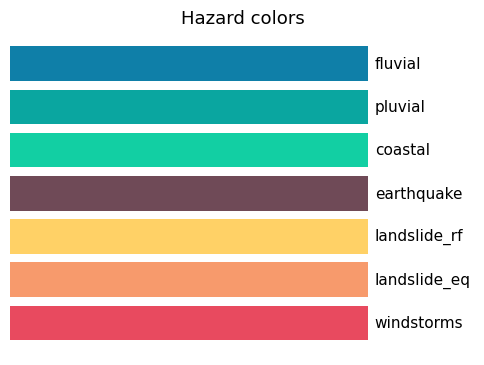

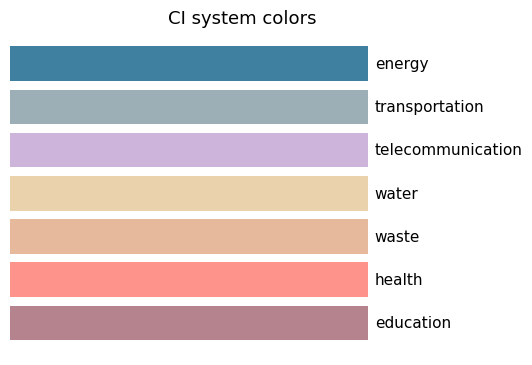

In [9]:
hazard_colors = {
    "fluvial": "#0F7FA8",        # deep river blue
    "pluvial": "#0AA6A0",        # blue-green teal
    "coastal": "#12CFA3",        # fresh sea green
    "earthquake": "#6F4A57",     # muted dark mauve
    "landslide_rf": "#FFD166",  # rainfall-triggered (yellow)
    "landslide_eq": "#F79A6C",  # EQ-triggered (orange-peach)
    "windstorms": "#E84A5F"     # strong warm red-pink
}


ci_sys_colors = {
    "energy": "#3F7FA0",            # slightly deeper muted blue
    "transportation": "#9CAFB7",    # cool grey-blue
    "telecommunication": "#CDB4DB", # soft lavender
    "water": "#EAD2AC",             # warm sand
    "waste": "#E6B89C",             # peach
    "health": "#FE938C",            # soft coral
    "education": "#B5838D"          # muted rose (anchor)
}


def plot_color_dict(color_dict, title):
    fig, ax = plt.subplots(figsize=(6, len(color_dict) * 0.6))
    
    for i, (label, color) in enumerate(color_dict.items()):
        ax.barh(i, 1, color=color)
        ax.text(1.02, i, label, va='center', fontsize=11)
    
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlim(0, 1.3)
    ax.set_title(title, fontsize=13)
    ax.invert_yaxis()
    ax.set_frame_on(False)
    
    plt.show()

# Plot both palettes
plot_color_dict(hazard_colors, "Hazard colors")
plot_color_dict(ci_sys_colors, "CI system colors")

# Create figure 2: plotbars with whiskers

In [11]:
data_pan_a =  hazard_dict['multi-hazard'][['total_min', 'total_Q1','total_Q2','total_Q3','total_max',]].sum().to_list()

In [13]:
data_pan_c = []
for hazard_type in hazard_types:
    data_pan_c.append(hazard_dict[hazard_type][['total_min', 'total_Q1','total_Q2','total_Q3','total_max',]].sum().to_list())

data_pan_b = []
for hazard_data in data_pan_c: data_pan_b.append(hazard_data[2]) # put the median of each hazard in a list
data_pan_b = [x / sum(data_pan_b) for x in data_pan_b] # divide by total

In [17]:
data_pan_e = []
data_range = ['min', 'Q1','Q2','Q3','max']
ci_system_totals_df = hazard_dict['multi-hazard'][['GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NAME_2','GID_2', 'geometry']]
for ci_system in cis_dict:
    sub_system_lst = ['{}'.format(sub_system) 
                        for sub_system in cis_dict[ci_system] ]

    data_ci = []
    for drange in data_range :
        column_names = ['{}_{}'.format(sub_system, drange) for sub_system in sub_system_lst]
        print(column_names)
        data_ci.append(hazard_dict['multi-hazard'][column_names].sum().sum())

    data_pan_e.append(data_ci) # save data list per ci_system

data_pan_d = []
for system_data in data_pan_e: data_pan_d.append(system_data[2]) # put the median of each hazard in a list
data_pan_d = [x / sum(data_pan_d) for x in data_pan_d] # divide by total

['power_min']
['power_Q1']
['power_Q2']
['power_Q3']
['power_max']
['road_min', 'air_min', 'rail_min']
['road_Q1', 'air_Q1', 'rail_Q1']
['road_Q2', 'air_Q2', 'rail_Q2']
['road_Q3', 'air_Q3', 'rail_Q3']
['road_max', 'air_max', 'rail_max']
['water_supply_min']
['water_supply_Q1']
['water_supply_Q2']
['water_supply_Q3']
['water_supply_max']
['waste_solid_min', 'waste_water_min']
['waste_solid_Q1', 'waste_water_Q1']
['waste_solid_Q2', 'waste_water_Q2']
['waste_solid_Q3', 'waste_water_Q3']
['waste_solid_max', 'waste_water_max']
['telecom_min']
['telecom_Q1']
['telecom_Q2']
['telecom_Q3']
['telecom_max']
['healthcare_min']
['healthcare_Q1']
['healthcare_Q2']
['healthcare_Q3']
['healthcare_max']
['education_min']
['education_Q1']
['education_Q2']
['education_Q3']
['education_max']


In [20]:
def to_billions_no_decimals(x, pos):
    return f"{x/1e9:.0f}"

def to_billions(x, pos):
    b = x / 1e9
    if b < 1:
        return f"{b:.1f}" 
    return f"{b:.0f}"      

hazard_label_map = {
    "fluvial": "Fluvial\nflooding",
    "pluvial": "Pluvial\nflooding",
    "coastal": "Coastal\nflooding",
    "earthquake": "Earthquakes",
    "landslide_rf": "Rainfall\n-triggered\nlandslides",
    "landslide_eq": "Earthquake\n-triggered\nlandslides",
    "windstorm": "Tropical\ncyclones"
}

hazard_types

cis_label_map = {
    "energy":  "Energy",
    "transportation":  "Transportation",
    "water":  "Water",
    "waste":  "Waste",
    "telecommunication": "Telecom\n-munications",
    "healthcare": "Healthcare", 
    "education": "Education"
    }

ci_order = list(cis_dict.keys())

C:\Users\snn490\AppData\Local\Temp\ipykernel_11852\4254813462.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  f6_ax3.set_ylim(0, 1000e9)#400e9)
C:\Users\snn490\AppData\Local\Temp\ipykernel_11852\4254813462.py:133: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  f6_ax5.set_ylim(0.0, 1000e9)#700e9)


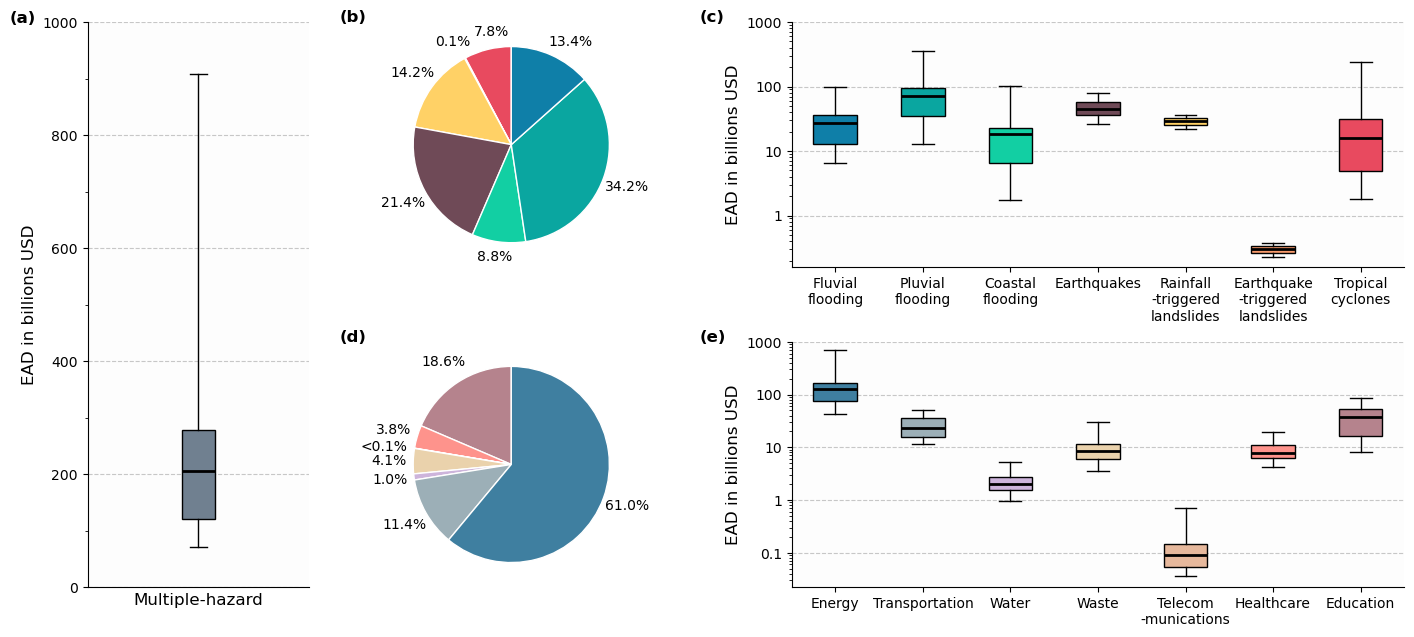

In [21]:
fig6 = plt.figure(constrained_layout=False, figsize=(18, 9)) # Create the figure
gs = fig6.add_gridspec(11, 18) # Create a 4x2 grid (4 rows and 2 columns) 

# Define the individual panels within the grid
f6_ax1 = fig6.add_subplot(gs[2:11, 0:3])  # First row, first column
f6_ax2 = fig6.add_subplot(gs[2:6, 3:8])  # First row, second column
f6_ax3 = fig6.add_subplot(gs[2:6, 9:17])  # First row, third column
f6_ax4 = fig6.add_subplot(gs[7:11, 3:8])  # First row, first column
f6_ax5 = fig6.add_subplot(gs[7:11, 9:17])  # First row, second column

f6_ax1.boxplot(data_pan_a,
    vert=True,
    patch_artist=True,
    whis=(0, 100),     
    showfliers=False,
    boxprops=dict(facecolor='slategrey', color="black"), #edede9'
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2))

# Create the pie chart
wedges_ax2, texts_ax2, autotexts_ax2 = f6_ax2.pie(
    data_pan_b[::-1],
    labels=None,                    # remove hazard labels
    colors=list(hazard_colors.values())[::-1],
    autopct='%1.1f%%',              # keep percentages
    pctdistance=1.25,               # move percentages outside
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}# textprops={'fontsize': 11}
)

manual_adjustments = {    0: (-0.20, 1.15),
                      1: (-0.6, 1.05),
                    4: (-0.17, -1.14 ),
                      6: (0.6, 1.05 ),
                    }
for i, autotext in enumerate(autotexts_ax2):
    if i in manual_adjustments:
        autotext.set_position(manual_adjustments[i])


# Plot the whisker plot in f6_ax3
bp = f6_ax3.boxplot(
    data_pan_c,
    vert=True,
    patch_artist=True,
    whis=(0, 100),
    showfliers=False,
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2))

for box, color in zip(bp['boxes'], hazard_colors.values()):
    box.set_facecolor(color)

# Create the pie chart
wedges_ax4, texts_ax4, autotexts_ax4 = f6_ax4.pie(
    data_pan_d[::-1],
    labels=None,                    # remove hazard labels
    colors=list(ci_sys_colors.values())[::-1],
    autopct='%1.1f%%',              # keep percentages
    pctdistance=1.25,               # move percentages outside
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    # textprops={'fontsize': 11}
)

for autotext in autotexts_ax4:
    if autotext.get_text() == "0.0%":
        autotext.set_text("<0.1%")
        autotext.set_position((-1.3, 0.18))
        
# Plot the whisker plot in f6_ax5
bp = f6_ax5.boxplot(
    data_pan_e,
    vert=True,
    patch_artist=True,
    whis=(0, 100),
    showfliers=False,
    boxprops=dict(edgecolor="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black", linewidth=2))

for box, color in zip(bp['boxes'], ci_sys_colors.values()):
    box.set_facecolor(color)

# Customize the whisker plot
# f6_ax1.set_title("Multiple Hazard EAD", fontsize=16)
f6_ax1.set_ylabel("EAD in billions USD", fontsize=12)
f6_ax1.set_xlabel("Multiple-hazard", fontsize=12)
f6_ax1.yaxis.set_major_formatter(FuncFormatter(to_billions_no_decimals))
f6_ax1.yaxis.set_minor_locator(MultipleLocator(100e9))
f6_ax1.set_ylim(0, 1000e9)
f6_ax1.grid(axis='y', linestyle='--', alpha=0.7)
f6_ax1.set_xticklabels([])
f6_ax1.set_xticks([])
f6_ax1.spines['top'].set_visible(False)
f6_ax1.spines['right'].set_visible(False)
f6_ax1.set_facecolor('#fdfdfd')  # very light grey

# Customize the pie chart
# f6_ax2.set_title('Relative EAD per hazard')

# Customize the whisker plot
# f6_ax3.set_title("EAD per hazard", fontsize=16)
f6_ax3.set_ylabel("EAD in billions USD", fontsize=12)
f6_ax3.set_yscale('log')
f6_ax3.yaxis.set_major_formatter(FuncFormatter(to_billions_no_decimals))
f6_ax3.set_ylim(0, 1000e9)#400e9)
f6_ax3.grid(axis='y', linestyle='--', alpha=0.7)
f6_ax3.set_xticks(range(1, len(hazard_types) + 1))
f6_ax3.set_xticklabels(
    [hazard_label_map[h] for h in hazard_types],
    rotation=0,   # keep readable; use 45 if space is tight
  #  fontsize=11
)
f6_ax3.spines['top'].set_visible(False)
f6_ax3.spines['right'].set_visible(False)
f6_ax3.set_facecolor('#fdfdfd')  # very light grey

# Customize the pie chart
# f6_ax4.set_title('Relative EAD per CI system')

# Customize the whisker plot
# f6_ax5.set_title("EAD per ci system", fontsize=16)
f6_ax5.set_ylabel("EAD in billions USD", fontsize=12)
f6_ax5.set_yscale("log")
f6_ax5.yaxis.set_major_formatter(FuncFormatter(to_billions))
f6_ax5.set_ylim(0.0, 1000e9)#700e9)
# f7_ax3.set_yticks([0, 0.1, 1, 10, 100, 1000])
f6_ax5.grid(axis='y', linestyle='--', alpha=0.7)
f6_ax5.set_xticks(range(1, len(ci_order) + 1))
f6_ax5.set_xticklabels(
    [cis_label_map[c] for c in ci_order],
    rotation=0
)
f6_ax5.spines['top'].set_visible(False)
f6_ax5.spines['right'].set_visible(False)
f6_ax5.set_facecolor('#fdfdfd')  # very light grey

# Panel labels
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)']
axes = [f6_ax1, f6_ax2, f6_ax3, f6_ax4, f6_ax5]

# Per-panel (x, y) coordinates in axes space
label_positions = [
    (-0.35, 1.02),  # (a) 
    (-0.20, 1.05),  # (b)
    (-0.15, 1.05),  # (c)
    (-0.20, 1.05),  # (d)
    (-0.15, 1.05)   # (e)
]

for ax, label, (x, y) in zip(axes, panel_labels, label_positions):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left')

fig6.savefig(figures_path / "Figure_2_global_overview.png", dpi=300, bbox_inches="tight")

# Create plotbars multiple-hazard risk per country

In [22]:
data_plotbar = []
top_df = hazard_dict['multi-hazard'][['COUNTRY', 'total_Q2']].groupby('COUNTRY').sum().sort_values('total_Q2', ascending = False)[0:20]
top_10 = top_df.index[0:20] # top 10 countries with highest risk

for hazard_type in hazard_types:
    hazard_df = hazard_dict[hazard_type][['COUNTRY', 'total_Q2']].groupby('COUNTRY').sum().loc[top_10]
    hazard_df = hazard_df.rename(columns={'total_Q2': hazard_type})
    top_df = top_df.merge(hazard_df[[hazard_type]], on='COUNTRY', how='left')

top_df = top_df.iloc[::-1].drop(columns=['total_Q2']) #reversed order
top_df = top_df.rename(columns={'windstorm': 'windstorms'})


In [23]:
top_df

,fluvial,pluvial,coastal,earthquake,landslide_rf,landslide_eq,windstorms
COUNTRY,,,,,,,
Vietnam,1.246028e+09,4.344143e+08,9.722215e+07,1.678589e+07,1.490134e+08,7.300884e+05,5.030130e+07
Austria,1.604232e+08,1.230691e+09,0.000000e+00,2.944024e+08,3.255974e+08,1.210591e+06,0.000000e+00
Philippines,1.078437e+08,4.223056e+08,1.091804e+08,4.954806e+08,9.336202e+07,4.856605e+06,8.782430e+08
Netherlands,1.395769e+07,1.300632e+08,1.873096e+09,1.292666e+08,9.737799e+06,0.000000e+00,0.000000e+00
South Korea,3.319094e+07,9.153687e+08,6.669225e+08,3.141784e+07,2.742029e+08,3.405413e+04,3.147635e+08
Greece,1.619963e+08,4.423092e+08,2.261725e+07,1.222384e+09,3.837971e+08,1.447336e+07,0.000000e+00
Brazil,9.936173e+08,7.717414e+08,1.631388e+08,1.509265e+05,5.409176e+08,0.000000e+00,0.000000e+00
Spain,4.683395e+08,8.672564e+08,2.471579e+07,3.761382e+08,9.430852e+08,7.274200e+05,6.836812e+07
Russia,8.545346e+08,1.498840e+09,4.466855e+07,1.912955e+08,3.518701e+08,8.814510e+05,1.591866e+07


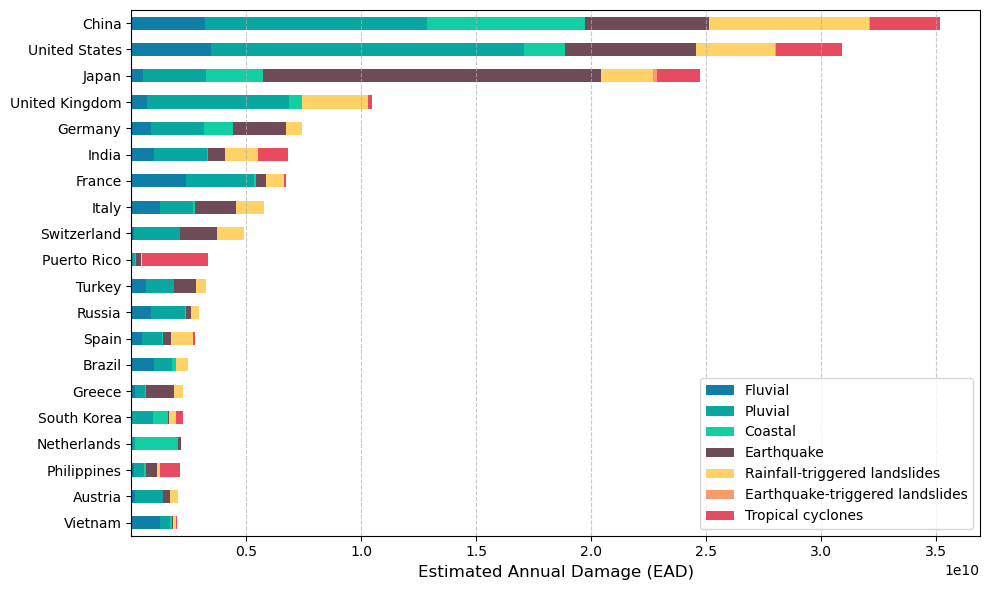

In [24]:
# Ensure the columns in `top_df` correspond to hazard types
# Extract colors based on the columns in the DataFrame
color_list = [hazard_colors[hazard] for hazard in top_df.columns]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Create a horizontal stacked bar plot using the color list
top_df.plot(kind='barh', stacked=True, ax=ax, color=color_list)

# Customize the plot
ax.set_title('')  # Remove the figure title
ax.set_ylabel('')  # Remove the y-axis title
ax.set_xlabel('Estimated Annual Damage (EAD)', fontsize=12)  # Adjust x-axis label

# Adjust legend hazard type names
legend_labels = {
    "fluvial": "Fluvial",
    "pluvial": "Pluvial",
    "coastal": "Coastal",
    "earthquake": "Earthquake",
    "landslide_rf": "Rainfall-triggered landslides",
    "landslide_eq": "Earthquake-triggered landslides",
    "windstorms": "Tropical cyclones"}

ax.legend(    labels=[legend_labels[hazard] for hazard in top_df.columns],  # Map to legend-friendly names
    #title='Hazard Type',
    loc='lower right')

# Add grid for x-axis
ax.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()

#figures_path = Path('C:\\Users\snn490\OneDrive - Vrije Universiteit Amsterdam\WorldBank_Projects\SupplyChainECA')
#plt.savefig(figures_path / 'bars_risk_without_cutoff.png', bbox_inches='tight', dpi=300)

plt.show()


# Create figure 6: top 20 multiple panel risk per country

## panel a

In [28]:
data_pan_a =  hazard_dict['multi-hazard'][['COUNTRY', 'total_min', 'total_Q1','total_Q2','total_Q3','total_max',]].groupby('COUNTRY').sum().sort_values('total_Q2', ascending = False)[0:20]
top_20_risk = data_pan_a.index[0:20] # top 20 countries with highest risk

dominant_hazard = top_df.idxmax(axis=1) # Dominant hazard per country = column with highest value
dominant_colors_a = dominant_hazard.map(hazard_colors) # Map to colors
dominant_colors_a = dominant_colors_a.iloc[::-1]


In [29]:
top_df

,fluvial,pluvial,coastal,earthquake,landslide_rf,landslide_eq,windstorms
COUNTRY,,,,,,,
Vietnam,1.246028e+09,4.344143e+08,9.722215e+07,1.678589e+07,1.490134e+08,7.300884e+05,5.030130e+07
Austria,1.604232e+08,1.230691e+09,0.000000e+00,2.944024e+08,3.255974e+08,1.210591e+06,0.000000e+00
Philippines,1.078437e+08,4.223056e+08,1.091804e+08,4.954806e+08,9.336202e+07,4.856605e+06,8.782430e+08
Netherlands,1.395769e+07,1.300632e+08,1.873096e+09,1.292666e+08,9.737799e+06,0.000000e+00,0.000000e+00
South Korea,3.319094e+07,9.153687e+08,6.669225e+08,3.141784e+07,2.742029e+08,3.405413e+04,3.147635e+08
Greece,1.619963e+08,4.423092e+08,2.261725e+07,1.222384e+09,3.837971e+08,1.447336e+07,0.000000e+00
Brazil,9.936173e+08,7.717414e+08,1.631388e+08,1.509265e+05,5.409176e+08,0.000000e+00,0.000000e+00
Spain,4.683395e+08,8.672564e+08,2.471579e+07,3.761382e+08,9.430852e+08,7.274200e+05,6.836812e+07
Russia,8.545346e+08,1.498840e+09,4.466855e+07,1.912955e+08,3.518701e+08,8.814510e+05,1.591866e+07


In [30]:
data_pan_a

,total_min,total_Q1,total_Q2,total_Q3,total_max
COUNTRY,,,,,
China,1.135153e+10,1.946549e+10,3.515056e+10,4.706231e+10,1.718869e+11
United States,1.066036e+10,1.794030e+10,3.088703e+10,4.259306e+10,1.122128e+11
Japan,1.241877e+10,1.703250e+10,2.472848e+10,3.205476e+10,1.102069e+11
United Kingdom,2.638388e+09,6.209744e+09,1.046945e+10,1.343971e+10,7.447549e+10
Germany,2.226219e+09,4.468947e+09,7.416862e+09,9.231406e+09,3.783596e+10
India,2.401031e+09,4.079954e+09,6.823666e+09,9.463900e+09,2.855468e+10
France,2.274752e+09,3.874540e+09,6.727146e+09,8.944474e+09,2.648050e+10
Italy,2.528163e+09,3.869674e+09,5.784718e+09,7.426385e+09,1.898600e+10
Switzerland,2.061137e+09,3.477357e+09,4.913216e+09,6.005577e+09,2.130112e+10


## panel b

In [31]:
gdp_country = pd.read_csv(r"Z:\snn490\Outputs\gmhcira\figures and others\gdp_current\GDP_PPP_constant_2021\API_NY.GDP.MKTP.PP.KD_DS2_en_csv_v2_4617.csv",skiprows=4)

# Select relevant columns
gdp_country = gdp_country[["Country Name", "Country Code", "2020"]].copy()

# Rename columns
gdp_country = gdp_country.rename(columns={
    "Country Name": "COUNTRY",
    "Country Code": "GID_0",
    "2020": "GDP_PPP_2020"})

country_risk_df = (hazard_dict['multi-hazard'][['COUNTRY', 'GID_0', 'total_min', 'total_Q1', 'total_Q2', 'total_Q3', 'total_max']]
    .groupby(['GID_0', 'COUNTRY'], as_index=False).sum().sort_values('total_Q2', ascending=False))

country_risk_df = country_risk_df.merge(gdp_country[['GID_0', 'GDP_PPP_2020']], on='GID_0', how='left')

In [34]:
risk_cols = ["total_min", "total_Q1", "total_Q2", "total_Q3", "total_max"]
relative_gdp = country_risk_df.copy()

# Compute risk as % of GDP
for c in risk_cols:
    relative_gdp[c] = 100 * relative_gdp[c] / relative_gdp["GDP_PPP_2020"]

risk_cols = ["total_min", "total_Q1", "total_Q2", "total_Q3", "total_max"]

### top 20 without differentiation

In [35]:
data_pan_b = (relative_gdp.set_index("COUNTRY")[risk_cols].sort_values("total_Q2", ascending=False).head(20))
data_pan_b.loc["Saint Vincent and the Grenadines", "total_min"] = 0.11 # to avoid plotting issues

In [36]:
data_pan_b

,total_min,total_Q1,total_Q2,total_Q3,total_max
COUNTRY,,,,,
Nauru,14.747911,17.600210,20.711589,23.566005,32.352118
Tonga,12.939923,15.814520,19.887545,23.529472,42.657018
Tuvalu,1.176366,3.582432,9.321518,11.760648,52.382189
Marshall Islands,1.728032,2.304107,3.356034,4.391962,9.474877
Vanuatu,1.731978,2.260096,3.252233,4.095844,9.306072
Micronesia,1.847426,2.343891,3.145227,4.117805,7.115076
Puerto Rico,0.170690,0.754267,2.518707,3.825205,21.644336
Malta,1.057017,1.315445,1.553256,1.810986,2.787672
Armenia,0.390485,0.720049,1.134888,1.436710,5.207741


In [37]:
# Top 20 countries by relative GDP risk (data_pan_b is indexed by COUNTRY)
top_20_b = data_pan_b.index[:20]

# Start an empty df with the right index
top_df_b = pd.DataFrame(index=top_20_b)

for hazard_type in hazard_types:
    hazard_df = (hazard_dict[hazard_type][['COUNTRY', 'total_Q2']]
        .groupby('COUNTRY', as_index=True)
        .sum()
        .rename(columns={'total_Q2': hazard_type}))
    
    # Join only the selected top-20 countries
    top_df_b = top_df_b.join(hazard_df.loc[top_20_b], how='left')

# fill missing hazards with 0 (common if a country has no risk for a hazard)
top_df_b = top_df_b.fillna(0)

# standardize windstorm naming
top_df_b = top_df_b.rename(columns={'windstorm': 'windstorms'})

dominant_hazard_b = top_df_b.idxmax(axis=1) # Dominant hazard per country = column with highest value
dominant_colors_b = dominant_hazard_b.map(hazard_colors) # Map to colors


In [38]:
top_df_b 

,fluvial,pluvial,coastal,earthquake,landslide_rf,landslide_eq,windstorms
COUNTRY,,,,,,,
Nauru,0.000000e+00,3.206035e+05,1.779819e+06,0.000000e+00,2.515999e+07,0.000000e+00,0.000000e+00
Tonga,0.000000e+00,8.670665e+06,1.369780e+06,1.917158e+07,1.084353e+08,5.251595e+02,9.093839e+06
Tuvalu,0.000000e+00,1.729461e+05,4.813496e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.000573e+04
Marshall Islands,0.000000e+00,7.999888e+05,8.332803e+06,0.000000e+00,0.000000e+00,0.000000e+00,6.449515e+04
Vanuatu,3.415850e+01,7.107364e+06,1.445205e+05,8.666116e+06,1.291132e+07,1.021288e+05,2.754233e+06
Micronesia,0.000000e+00,1.230451e+06,1.139656e+07,1.465480e+05,7.227109e+04,0.000000e+00,5.927983e+05
Puerto Rico,2.048276e+04,1.772854e+08,9.494492e+06,2.135282e+08,4.356156e+07,2.073583e+03,2.876419e+09
Malta,0.000000e+00,2.078834e+07,7.332713e+04,1.445205e+08,2.380665e+08,0.000000e+00,0.000000e+00
Armenia,5.783920e+07,2.124673e+08,0.000000e+00,2.244165e+08,1.062007e+07,5.817682e+05,0.000000e+00


### without SIDS

In [39]:
# https://www.un.org/ohrlls/content/list-sids 
# https://www.un.org/ohrlls/content/about-small-island-developing-states

sids_dict = {
    # Caribbean
    "ATG": "Antigua and Barbuda", #
    "BHS": "Bahamas", #
    "BRB": "Barbados", #
    "BLZ": "Belize", #
    "CUB": "Cuba", #
    "DMA": "Dominica", #
    "DOM": "Dominican Republic", #
    "GUY": "Guyana", #
    "GRD": "Grenada", #
    "HTI": "Haiti", #
    "JAM": "Jamaica", #
    "KNA": "Saint Kitts and Nevis", #
    "LCA": "Saint Lucia", #
    "VCT": "Saint Vincent and the Grenadines", #
    "SUR": "Suriname", #
    "TTO": "Trinidad and Tobago", #

    # Atlantic & Indian Ocean
    "CPV": "Cabo Verde", #
    "COM": "Comoros", #
    "GNB": "Guinea-Bissau", #
    "MDV": "Maldives", #
    "MUS": "Mauritius", #
    "STP": "São Tomé and Príncipe", #
    "SYC": "Seychelles", #
    "SGP": "Singapore", #

    # Pacific
    "COK": "Cook Islands", #
    "FJI": "Fiji", #
    "KIR": "Kiribati", #
    "MHL": "Marshall Islands", #
    "FSM": "Micronesia (Federated States of)", #
    "NRU": "Nauru", #
    "NIU": "Niue", 
    "PLW": "Palau", #
    "PNG": "Papua New Guinea", #
    "WSM": "Samoa",#
    "SLB": "Solomon Islands", #
    "TLS": "Timor-Leste", #
    "TON": "Tonga", #
    "TUV": "Tuvalu", #
    "VUT": "Vanuatu" #
}

associate_members_dict = {
    "ASM": "American Samoa", #
    "AIA": "Anguilla", #
    "ABW": "Aruba", #
    "BMU": "Bermuda", #
    "VGB": "British Virgin Islands", #
    "CYM": "Cayman Islands", #
    "MNP": "Commonwealth of the Northern Mariana Islands", #
    "CUW": "Curaçao", #
    "PYF": "French Polynesia", #
    "GLP": "Guadeloupe", #
    "GUM": "Guam", #
    "MTQ": "Martinique", #
    "MSR": "Montserrat", #
    "NCL": "New Caledonia", #
    "PRI": "Puerto Rico", #
    "SXM": "Sint Maarten", #
    "TCA": "Turks and Caicos Islands", #
    "VIR": "U.S. Virgin Islands" #
}

# check if all ISO 3 codes are in the GADM_countries
# Get the set of GID_0 codes present in GADM
gadm_codes = set(gadm_countries["GID_0"].unique())

# Check SIDS
missing_sids = [k for k in sids_dict.keys() if k not in gadm_codes]

# Check Associate Members
missing_associates = [k for k in associate_members_dict.keys() if k not in gadm_codes]

print("Missing SIDS in GADM:")
print(missing_sids)

print("\nMissing Associate Members in GADM:")
print(missing_associates)

Missing SIDS in GADM:
[]

Missing Associate Members in GADM:
[]


In [40]:
# Combine ISO3 codes (keys) from both dictionaries
sids_iso3 = set(sids_dict.keys()) | set(associate_members_dict.keys())

# Filter out SIDS + Associate Members
relative_gdp_non_sids = relative_gdp.loc[~relative_gdp["GID_0"].isin(sids_iso3)].copy()

data_pan_b = (relative_gdp_non_sids.set_index("COUNTRY")[risk_cols].sort_values("total_Q2", ascending=False).head(20))
data_pan_b.loc[data_pan_b["total_min"] < 0.10, "total_min"] = 0.11 #avoiding plotting additional ticks

# Top 20 countries by relative GDP risk (data_pan_b is indexed by COUNTRY)
top_20_b = data_pan_b.index[:20]

# Start an empty df with the right index
top_df_b = pd.DataFrame(index=top_20_b)

for hazard_type in hazard_types:
    hazard_df = (hazard_dict[hazard_type][['COUNTRY', 'total_Q2']]
        .groupby('COUNTRY', as_index=True)
        .sum()
        .rename(columns={'total_Q2': hazard_type}))
    
    # Join only the selected top-20 countries
    top_df_b = top_df_b.join(hazard_df.loc[top_20_b], how='left')

# fill missing hazards with 0 (common if a country has no risk for a hazard)
top_df_b = top_df_b.fillna(0)

# standardize windstorm naming
top_df_b = top_df_b.rename(columns={'windstorm': 'windstorms'})

dominant_hazard_b = top_df_b.idxmax(axis=1) # Dominant hazard per country = column with highest value
dominant_colors_b = dominant_hazard_b.map(hazard_colors) # Map to colors


In [41]:
data_pan_b

,total_min,total_Q1,total_Q2,total_Q3,total_max
COUNTRY,,,,,
Malta,1.057017,1.315445,1.553256,1.810986,2.787672
Armenia,0.390485,0.720049,1.134888,1.436710,5.207741
Lesotho,0.459920,0.659534,0.972641,1.288665,2.046789
Switzerland,0.308579,0.520605,0.735572,0.899112,3.189051
Greece,0.356505,0.526897,0.689083,0.857249,2.245907
Laos,0.260050,0.349673,0.580846,0.760048,1.445974
Bhutan,0.289416,0.387862,0.574465,0.722071,1.278159
Central African Republic,0.110000,0.182929,0.540363,0.783572,2.633856
Afghanistan,0.171277,0.310325,0.531243,0.730836,2.225002


## panel C: sids

In [42]:
# Filter out SIDS + Associate Members
relative_gdp_sids = relative_gdp.loc[relative_gdp["GID_0"].isin(sids_iso3)].copy()

data_pan_c = (relative_gdp_sids.set_index("COUNTRY")[risk_cols].sort_values("total_Q2", ascending=False).head(20))
data_pan_c.loc[data_pan_c["total_min"] < 0.12, "total_min"] = 0.13 #avoiding plotting additional ticks

# Top 20 countries by relative GDP risk (data_pan_b is indexed by COUNTRY)
top_20_c = data_pan_c.index[:20]

# Start an empty df with the right index
top_df_c = pd.DataFrame(index=top_20_c)

for hazard_type in hazard_types:
    hazard_df = (hazard_dict[hazard_type][['COUNTRY', 'total_Q2']].groupby('COUNTRY', as_index=True).sum().rename(columns={'total_Q2': hazard_type}))
    
    # Join only the selected top-20 countries
    top_df_c = top_df_c.join(hazard_df.loc[top_20_c], how='left')

# fill missing hazards with 0 (common if a country has no risk for a hazard)
top_df_c = top_df_c.fillna(0)

# standardize windstorm naming
top_df_c = top_df_c.rename(columns={'windstorm': 'windstorms'})

dominant_hazard_c = top_df_c.idxmax(axis=1) # Dominant hazard per country = column with highest value
dominant_colors_c = dominant_hazard_c.map(hazard_colors) # Map to colors


In [43]:
data_pan_c

,total_min,total_Q1,total_Q2,total_Q3,total_max
COUNTRY,,,,,
Nauru,14.747911,17.600210,20.711589,23.566005,32.352118
Tonga,12.939923,15.814520,19.887545,23.529472,42.657018
Tuvalu,1.176366,3.582432,9.321518,11.760648,52.382189
Marshall Islands,1.728032,2.304107,3.356034,4.391962,9.474877
Vanuatu,1.731978,2.260096,3.252233,4.095844,9.306072
Micronesia,1.847426,2.343891,3.145227,4.117805,7.115076
Puerto Rico,0.170690,0.754267,2.518707,3.825205,21.644336
Belize,0.268642,0.541313,1.124511,1.686363,4.054078
Bahamas,0.403627,0.641091,1.050464,1.447289,3.025834


## panel D: per income group and hazard

In [44]:
data_pan_d =  hazard_dict['multi-hazard'][['COUNTRY', 'total_min', 'total_Q1','total_Q2','total_Q3','total_max',]].groupby('COUNTRY').sum().sort_values('total_Q2', ascending = False)


In [45]:
data_pan_d = (hazard_dict['multi-hazard'][['COUNTRY', 'total_min', 'total_Q1', 'total_Q2', 'total_Q3', 'total_max']].groupby('COUNTRY', as_index=False).sum())
country_meta = gadm_countries[['COUNTRY', 'Region', 'Income group']].drop_duplicates()

data_pan_d = data_pan_d.merge(country_meta, on='COUNTRY', how='left')
print(data_pan_d[['Region', 'Income group']].isna().sum()) # check, should be zero for both

risk_by_region = (data_pan_d.groupby('Region', as_index=False)[risk_cols].sum().sort_values('total_Q2', ascending=False))
risk_by_income = (data_pan_d.groupby('Income group', as_index=False)[risk_cols].sum().sort_values('total_Q2', ascending=False))

Region          0
Income group    0
dtype: int64


In [46]:
# Start with country + group info
meta = gadm_countries[['COUNTRY', 'Region', 'Income group']].drop_duplicates()

# Initialize df with metadata
hazard_country = meta.copy()

# Add one column per hazard (total_Q2)
for hazard in hazard_types:
    tmp = (hazard_dict[hazard][['COUNTRY', 'total_Q2']].groupby('COUNTRY', as_index=False).sum().rename(columns={'total_Q2': hazard}))
    hazard_country = hazard_country.merge(tmp, on='COUNTRY', how='left')

# Fill missing hazards with 0
hazard_country[hazard_types] = hazard_country[hazard_types].fillna(0)

hazard_by_region = (hazard_country.groupby('Region', as_index=False)[hazard_types].sum())
dominant_hazard_region = hazard_by_region.set_index('Region').idxmax(axis=1)
hazard_by_income = (hazard_country.groupby('Income group', as_index=False)[hazard_types].sum())
dominant_hazard_income = hazard_by_income.set_index('Income group').idxmax(axis=1)

dominant_hazard_region = dominant_hazard_region.replace({"windstorm": "windstorms"})
dominant_hazard_income = dominant_hazard_income.replace({"windstorm": "windstorms"})
dominant_color_region = dominant_hazard_region.map(hazard_colors)
dominant_color_income = dominant_hazard_income.map(hazard_colors)

risk_by_region_df = risk_by_region.rename(columns={'Region': 'Grouped'})[['Grouped'] + risk_cols]
risk_by_income_df = risk_by_income.rename(columns={'Income group': 'Grouped'})[['Grouped'] + risk_cols]
dominant_color_region = dominant_color_region.reindex(risk_by_region_df.set_index('Grouped').index)
dominant_color_income = dominant_color_income.reindex(risk_by_income_df.set_index('Grouped').index)
data_pan_d_grouped = pd.concat([risk_by_income_df, risk_by_region_df], ignore_index=True)
dominant_color_grouped = pd.concat([dominant_color_income, dominant_color_region])


In [47]:
data_pan_d_grouped

,Grouped,total_min,total_Q1,total_Q2,total_Q3,total_max
0,High income,4.581972e+10,7.644846e+10,1.265664e+11,1.692274e+11,5.790983e+11
1,Upper middle income,1.870215e+10,3.195461e+10,5.723898e+10,7.753987e+10,2.454760e+11
2,Lower middle income,6.366089e+09,1.097793e+10,1.972739e+10,2.768715e+10,7.418661e+10
3,Low income,7.929719e+08,1.360960e+09,2.566419e+09,3.698858e+09,9.090513e+09
4,East Asia & Pacific,2.837510e+10,4.448858e+10,7.525012e+10,1.012129e+11,3.555708e+11
5,Europe & Central Asia,2.141164e+10,3.832704e+10,6.318188e+10,8.238736e+10,2.854416e+11
6,North America,1.120617e+10,1.884005e+10,3.260802e+10,4.526335e+10,1.204937e+11
7,Latin America & Caribbean,3.504954e+09,6.677211e+09,1.389288e+10,1.968507e+10,6.691027e+10
8,South Asia,3.331787e+09,5.728072e+09,9.857416e+09,1.365081e+10,3.925154e+10
9,Sub-Saharan Africa,1.802096e+09,3.430126e+09,5.998189e+09,8.200381e+09,2.485959e+10


In [49]:
# Create white spacing for data
top = data_pan_d_grouped.iloc[:4]
bottom = data_pan_d_grouped.iloc[4:]
empty_rows = pd.DataFrame([[None] * data_pan_d_grouped.shape[1]] * 3,columns=data_pan_d_grouped.columns)
data_pan_d_grouped = pd.concat([empty_rows,top, empty_rows, bottom, empty_rows],ignore_index=True)

# Create white spacing for colors
top_colors = dominant_color_grouped.iloc[:4]
bottom_colors = dominant_color_grouped.iloc[4:]
empty_colors = pd.Series(['#0AA6A0'] * 3)
dominant_color_grouped = pd.concat([empty_colors,top_colors, empty_colors, bottom_colors, empty_colors],ignore_index=False)


## plotting

C:\Users\snn490\AppData\Local\Temp\ipykernel_15168\4193024423.py:177: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f7_ax1.set_xlim(0, 1000e9)
C:\Users\snn490\AppData\Local\Temp\ipykernel_15168\4193024423.py:192: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f7_ax2.set_xlim(0, 100)
C:\Users\snn490\AppData\Local\Temp\ipykernel_15168\4193024423.py:211: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f7_ax3.set_xlim(0, 100)
C:\Users\snn490\AppData\Local\Temp\ipykernel_15168\4193024423.py:228: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  f7_ax4.set_xlim(0, 1000e9)


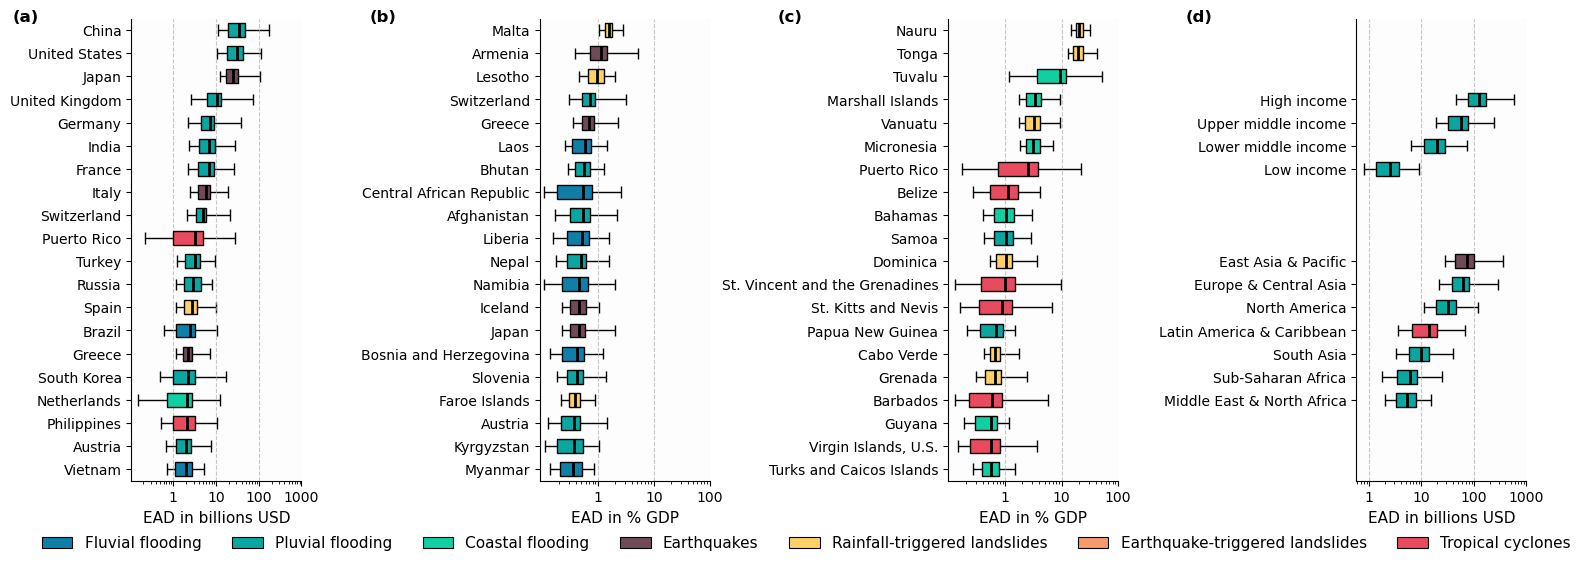

In [53]:
label_map = {    "Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
    "Saint Kitts and Nevis": "St. Kitts and Nevis",
    "Saint Lucia": "St. Lucia",
    "Antigua and Barbuda": "Antigua & Barbuda"}

hazard_label_map = {    "fluvial": "Fluvial flooding",
    "pluvial": "Pluvial flooding",
    "coastal": "Coastal flooding",
    "earthquake": "Earthquakes",
    "landslide_rf": "Rainfall-triggered landslides",
    "landslide_eq": "Earthquake-triggered landslides",
    "windstorms": "Tropical cyclones"}

legend_handles = [    Patch(facecolor=hazard_colors[h], edgecolor='black', linewidth=0.8, label=hazard_label_map[h]) for h in hazard_colors]

fig7 = plt.figure(constrained_layout=False, figsize=(18, 6))
gs = fig7.add_gridspec(1, 7)

f7_ax1 = fig7.add_subplot(gs[0, 0])
f7_ax2 = fig7.add_subplot(gs[0, 2])
f7_ax3 = fig7.add_subplot(gs[0, 4])
f7_ax4 = fig7.add_subplot(gs[0, 6])

#################
#plot a
#################
countries_a = data_pan_a.index.to_list()
y_a = np.arange(1, len(data_pan_a) + 1)

f7_ax1.hlines(y=y_a,
    xmin=data_pan_a["total_min"].to_numpy(),
    xmax=data_pan_a["total_max"].to_numpy(),
    colors="black",
    linewidth=1.0,
    zorder=1)

# --- Caps (to mimic boxplot caps)
cap_h = 0.25
f7_ax1.vlines(data_pan_a["total_min"].to_numpy(), y_a - cap_h, y_a + cap_h, colors="black", linewidth=1.0, zorder=1)
f7_ax1.vlines(data_pan_a["total_max"].to_numpy(), y_a - cap_h, y_a + cap_h, colors="black", linewidth=1.0, zorder=1)

# --- Box: Q1 → Q3
box_h = 0.6
f7_ax1.barh(y=y_a, width=(data_pan_a["total_Q3"] - data_pan_a["total_Q1"]).to_numpy(),
    left=data_pan_a["total_Q1"].to_numpy(),
    height=box_h,
    color=dominant_colors_a.to_list(),
    edgecolor="black",
    linewidth=1.0,
    zorder=2)

# --- Median: Q2
f7_ax1.vlines(data_pan_a["total_Q2"].to_numpy(),
    y_a - box_h / 2,
    y_a + box_h / 2,
    colors="black",
    linewidth=2.0,
    zorder=3)

#################
# subplot b
#################
countries_b = data_pan_b.index.to_list()
y_b = np.arange(1, len(data_pan_b) + 1)

#plot a
f7_ax2.hlines(y=y_b,
    xmin=data_pan_b["total_min"].to_numpy(),
    xmax=data_pan_b["total_max"].to_numpy(),
    colors="black",
    linewidth=1.0,
    zorder=1)

# --- Caps (to mimic boxplot caps)
cap_h = 0.25
f7_ax2.vlines(data_pan_b["total_min"].to_numpy(), y_b - cap_h, y_b + cap_h, colors="black", linewidth=1.0, zorder=1)
f7_ax2.vlines(data_pan_b["total_max"].to_numpy(), y_b - cap_h, y_b + cap_h,colors="black", linewidth=1.0, zorder=1)

# --- Box: Q1 → Q3
box_h = 0.6
f7_ax2.barh(y=y_b,
    width=(data_pan_b["total_Q3"] - data_pan_b["total_Q1"]).to_numpy(),
    left=data_pan_b["total_Q1"].to_numpy(),
    height=box_h,
    color=dominant_colors_b.to_list(),
    edgecolor="black",
    linewidth=1.0,
    zorder=2)

# --- Median: Q2
f7_ax2.vlines(data_pan_b["total_Q2"].to_numpy(),
    y_b - box_h / 2,
    y_b + box_h / 2,
    colors="black",
    linewidth=2.0,
    zorder=3)

#################
# subplot c
#################
countries_c = data_pan_c.index.to_list()
y_c = np.arange(1, len(data_pan_c) + 1)

f7_ax3.hlines(y=y_c,
    xmin=data_pan_c["total_min"].to_numpy(),
    xmax=data_pan_c["total_max"].to_numpy(),
    colors="black",
    linewidth=1.0,
    zorder=1)

cap_h = 0.25
f7_ax3.vlines(data_pan_c["total_min"].to_numpy(), y_c - cap_h, y_c + cap_h, colors="black", linewidth=1.0, zorder=1)
f7_ax3.vlines(data_pan_c["total_max"].to_numpy(), y_c - cap_h, y_c + cap_h,colors="black", linewidth=1.0, zorder=1)

box_h = 0.6
f7_ax3.barh(y=y_c,
    width=(data_pan_c["total_Q3"] - data_pan_c["total_Q1"]).to_numpy(),
    left=data_pan_c["total_Q1"].to_numpy(),
    height=box_h,
    color=dominant_colors_c.to_list(),
    edgecolor="black",
    linewidth=1.0,
    zorder=2)
f7_ax3.vlines(data_pan_c["total_Q2"].to_numpy(), y_c - box_h / 2, y_c + box_h / 2, colors="black", linewidth=2.0, zorder=3)

#################
# subplot d
#################
grouped_risk = data_pan_d_grouped['Grouped'].to_list()
y_d = np.arange(1, len(data_pan_d_grouped) + 1)

f7_ax4.hlines(y=y_d,
    xmin=data_pan_d_grouped["total_min"].to_numpy(),
    xmax=data_pan_d_grouped["total_max"].to_numpy(),
    colors="black",
    linewidth=1.0,
    zorder=1)

cap_h = 0.25
f7_ax4.vlines(data_pan_d_grouped["total_min"].to_numpy(), y_d - cap_h, y_d + cap_h, colors="black", linewidth=1.0, zorder=1)
f7_ax4.vlines(data_pan_d_grouped["total_max"].to_numpy(), y_d - cap_h, y_d + cap_h, colors="black", linewidth=1.0, zorder=1)

box_h = 0.6
f7_ax4.barh(y=y_d,
    width=(data_pan_d_grouped["total_Q3"] - data_pan_d_grouped["total_Q1"]).to_numpy(),
    left=data_pan_d_grouped["total_Q1"].to_numpy(),
    height=box_h,
    color=dominant_color_grouped.to_list(),
    edgecolor="black",
    linewidth=1.0,
    zorder=2)
f7_ax4.vlines(data_pan_d_grouped["total_Q2"].to_numpy(), y_d - box_h / 2, y_d + box_h / 2, colors="black", linewidth=2.0, zorder=3)

############
# arrange axis
##########
f7_ax1.set_yticks(y_a)
f7_ax1.set_yticklabels(countries_a)
f7_ax1.set_ylim(0.5, len(data_pan_a) + 0.5) # Reduce vertical white space
f7_ax1.invert_yaxis() #highest risk on top
f7_ax1.set_xlabel("EAD in billions USD", fontsize=11)
f7_ax1.grid(axis="x", linestyle="--", alpha=0.7)
f7_ax1.set_xscale('log')
f7_ax1.xaxis.set_major_formatter(FuncFormatter(to_billions_no_decimals))
f7_ax1.set_xlim(0, 1000e9)
f7_ax1.spines["top"].set_visible(False)
f7_ax1.spines["right"].set_visible(False)
f7_ax1.set_facecolor('#fdfdfd')  # very light grey

f7_ax2.set_yticks(y_b)
f7_ax2.set_yticklabels(countries_b)
f7_ax2.set_ylim(0.5, len(data_pan_b) + 0.5) # Reduce vertical white space
f7_ax2.invert_yaxis() #highest risk on top
f7_ax2.set_xlabel("EAD in % GDP", fontsize=11)
f7_ax2.grid(axis="x", linestyle="--", alpha=0.7)
f7_ax2.set_xscale('log')
# Use log ticks at powers of 10
f7_ax2.xaxis.set_major_locator(mticker.LogLocator(base=10))
# Format ticks as plain numbers (no 10^x)
f7_ax2.set_xlim(0, 100)
f7_ax2.set_xticks([1, 10, 100])
f7_ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{int(x)}"))
f7_ax2.spines["top"].set_visible(False)
f7_ax2.spines["right"].set_visible(False)
f7_ax2.set_facecolor('#fdfdfd')  # very light grey

f7_ax3.set_yticks(y_c)
f7_ax3.set_yticklabels([label_map.get(lbl, lbl) for lbl in countries_c])
f7_ax3.set_ylim(0.5, len(data_pan_c) + 0.5) # Reduce vertical white space
f7_ax3.invert_yaxis() #highest risk on top
f7_ax3.set_xlabel("EAD in % GDP", fontsize=11)
f7_ax3.grid(axis="x", linestyle="--", alpha=0.7)
f7_ax3.set_xscale('log')
# Use log ticks at powers of 10
f7_ax3.xaxis.set_major_locator(mticker.LogLocator(base=10))
# Format ticks as plain numbers (no 10^x)
f7_ax3.set_xlim(0, 100)
f7_ax3.set_xticks([1, 10, 100])
f7_ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{int(x)}"))
f7_ax3.spines["top"].set_visible(False)
f7_ax3.spines["right"].set_visible(False)
f7_ax3.set_facecolor('#fdfdfd')  # very light grey

f7_ax4.set_yticks(y_d)
f7_ax4.set_yticklabels(grouped_risk)
f7_ax4.set_ylim(0.5, len(data_pan_d_grouped) + 0.5) # Reduce vertical white space
f7_ax4.invert_yaxis() #highest risk on top
f7_ax4.set_xlabel("EAD in billions USD", fontsize=11)
f7_ax4.grid(axis="x", linestyle="--", alpha=0.7)
f7_ax4.set_xscale('log')
f7_ax4.xaxis.set_major_formatter(FuncFormatter(to_billions_no_decimals))
f7_ax4.set_xlim(0, 1000e9)
f7_ax4.spines["top"].set_visible(False)
f7_ax4.spines["right"].set_visible(False)
f7_ax4.set_facecolor('#fdfdfd')  # very light grey
empty_positions = [0, 1, 2, 7, 8, 9, 17, 18 ,19]
y_positions = range(len(data_pan_d_grouped))
for tick, pos in zip(f7_ax4.yaxis.get_major_ticks(), y_positions):
    if pos in empty_positions:
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)

# Panel labels
panel_labels = ['(a)', '(b)', '(c)', '(d)']
axes = [f7_ax1, f7_ax2, f7_ax3, f7_ax4]

# Per-panel (x, y) coordinates in axes space
label_positions = [
    (-0.7, 1.02),  # (a) — custom position
    (-1.0, 1.02),  # (b)
    (-1.0, 1.02),  # (c)
    (-1.0, 1.02),  # (d)
]

for ax, label, (x, y) in zip(axes, panel_labels, label_positions):
    ax.text(x, y, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left')

fig7.legend(handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.03),
    fontsize=11)

fig7.savefig(figures_path / "Figure_6_coutry_and_grouped_risk.png", dpi=300, bbox_inches="tight")